## Explicação das próximas células
As células a seguir importam as bibliotecas necessárias para análise de dados, carregam o arquivo CSV da PNS 2019, filtram a população idosa (60+), identificam pessoas saudáveis e pessoas com artrite/reumatismo, e preparam os dados para análise geográfica e visualização.

# Análise de Idosos Saudáveis - PNS 2019
Este notebook realiza uma análise exploratória dos dados da Pesquisa Nacional de Saúde (PNS) de 2019, focando na população idosa (60+), pessoas saudáveis, pessoas com artrite/reumatismo e pessoas com artrite/reumatismo puro. Todas as etapas são comentadas e explicadas para facilitar o entendimento.

In [1]:
# Importa as bibliotecas necessárias para análise de dados e visualização
import pandas as pd  # Biblioteca para manipulação de dados
import numpy as np  # Biblioteca para operações numéricas
import matplotlib.pyplot as plt  # Biblioteca para gráficos

### Importação das bibliotecas
Esta célula importa as bibliotecas pandas, numpy e matplotlib, que serão usadas para manipulação de dados e criação de gráficos.

In [2]:
# Carrega o arquivo CSV com os dados da PNS 2019
df = pd.read_csv("pns2019.csv")  # Lê o arquivo CSV
df = df[df['C008'] > 59] # selecionar apenas os registros maiores igual que 60 anos
print(df.shape)  # Mostra a quantidade de linhas e colunas do DataFrame filtrado

(43554, 1087)


### Carregamento e filtragem dos dados
Esta célula carrega o arquivo CSV da PNS 2019, filtra apenas os registros de pessoas com 60 anos ou mais e exibe a quantidade de linhas e colunas do DataFrame resultante.

In [3]:
# Define as colunas de doenças crônicas para análise
cols = ["Q00201","Q03001","Q060","Q06306","Q068",
        "Q074","Q079","Q088","Q092","Q11006","Q11604","Q120",'Q124',"Q128"] # colunas de doenças cronicas

# Filtra pessoas sem nenhuma doença crônica
df_bem = df[df[cols].eq(2).all(axis=1)] # filtrar apenas pessoas sem doença
print(f'Linhas e Colunas de Pessoas Bem {df_bem.shape}')  # Exibe a quantidade de pessoas saudáveis

# Filtra pessoas com artrite/reumatismo
df_atri_reu = df[df['Q079'] == 1] # filtrar apenas pessoa com artrite
print(f'Linhas e Colunas de Pessoas com artrite e reumatismo {df_atri_reu.shape}')  # Exibe a quantidade de pessoas com artrite/reumatismo

Linhas e Colunas de Pessoas Bem (4332, 1087)
Linhas e Colunas de Pessoas com artrite e reumatismo (4025, 1087)


### Identificação de pessoas saudáveis e com artrite/reumatismo
Esta célula define as colunas de doenças crônicas, filtra pessoas saudáveis (sem doenças crônicas) e pessoas com artrite/reumatismo, exibindo a quantidade de cada grupo.

In [4]:
# Remove a coluna 'Q079' da lista de colunas de doenças crônicas, pois será usada para filtrar artrite/reumatismo
cols.remove("Q079")
# Filtra pessoas que não possuem nenhuma das doenças crônicas (exceto artrite/reumatismo)
df_atri_reu_puro = df[ (df[cols].eq(2).all(axis=1))] 
# Seleciona apenas as pessoas que possuem artrite/reumatismo puro (sem outras doenças crônicas)
df_atri_reu_puro = df_atri_reu_puro[df_atri_reu_puro["Q079"] == 1]
# Exibe a quantidade de linhas e colunas do DataFrame resultante
print(f'Linhas e Colunas de Pessoas com  artrite e reumatismo pura {df_atri_reu_puro.shape}')

Linhas e Colunas de Pessoas com  artrite e reumatismo pura (472, 1087)


### Identificação de pessoas com artrite/reumatismo puro
Esta célula remove a coluna de artrite/reumatismo da lista de doenças crônicas, filtra pessoas sem outras doenças crônicas e seleciona apenas aquelas com artrite/reumatismo puro.

In [5]:
# Exibe o DataFrame de pessoas saudáveis (sem doenças crônicas)
df_bem

,V0001,V0024,UPA_PNS,V0006_PNS,V0015,V0020,V0022,V0026,V0031,V0025A,...,VDE002,VDE014,VDF002,VDF003,VDF004,VDL001,VDM001,VDP001,VDR001,VDDATA
60,11,1110011,110000034,8,1,2019,1.0,1,1,1.0,...,NaN,NaN,6298.0,6298.0,7.0,NaN,NaN,NaN,NaN,20210825
89,11,1110011,110000153,6,1,2019,3.0,1,1,1.0,...,NaN,NaN,2696.0,899.0,3.0,NaN,NaN,NaN,NaN,20210825
94,11,1110011,110000153,8,1,2019,2.0,1,1,1.0,...,1.0,5.0,3000.0,1500.0,4.0,NaN,NaN,NaN,NaN,20210825
156,11,1110011,110000584,7,1,2019,3.0,1,1,1.0,...,NaN,NaN,25340.0,8447.0,7.0,NaN,NaN,NaN,NaN,20210825
200,11,1110011,110001520,4,1,2019,4.0,1,1,1.0,...,1.0,1.0,10500.0,2625.0,5.0,NaN,1.0,NaN,NaN,20210825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293390,53,5310220,530017803,14,1,2019,3.0,2,1,1.0,...,NaN,NaN,2994.0,998.0,3.0,NaN,NaN,NaN,NaN,20210825
293417,53,5310220,530023953,9,1,2019,4.0,2,1,1.0,...,NaN,NaN,1900.0,475.0,2.0,NaN,NaN,NaN,NaN,20210825
293420,53,5310220,530023953,10,1,2019,1.0,2,1,1.0,...,NaN,NaN,920.0,920.0,3.0,NaN,NaN,NaN,NaN,20210825
293497,53,5310220,530028975,7,1,2019,1.0,2,1,1.0,...,1.0,1.0,1098.0,1098.0,4.0,NaN,1.0,1.0,NaN,20210825


### Visualização dos dados de pessoas saudáveis
Esta célula exibe o DataFrame das pessoas saudáveis, ou seja, aquelas sem nenhuma doença crônica.

In [6]:
# Exibe o DataFrame de pessoas com artrite/reumatismo
df_atri_reu

,V0001,V0024,UPA_PNS,V0006_PNS,V0015,V0020,V0022,V0026,V0031,V0025A,...,VDE002,VDE014,VDF002,VDF003,VDF004,VDL001,VDM001,VDP001,VDR001,VDDATA
248,11,1110011,110002149,8,1,2019,6.0,1,1,1.0,...,NaN,NaN,4998.0,833.0,3.0,NaN,NaN,NaN,NaN,20210825
607,11,1110011,110005705,4,1,2019,2.0,1,1,1.0,...,NaN,NaN,2000.0,1000.0,4.0,NaN,NaN,NaN,NaN,20210825
668,11,1110011,110005834,9,1,2019,2.0,1,1,1.0,...,1.0,4.0,14800.0,7400.0,7.0,NaN,NaN,NaN,NaN,20210825
717,11,1110011,110007557,12,1,2019,1.0,1,1,1.0,...,NaN,NaN,4480.0,4480.0,6.0,NaN,NaN,NaN,NaN,20210825
1117,11,1110011,110010545,7,1,2019,2.0,1,1,1.0,...,1.0,2.0,2043.0,1022.0,4.0,NaN,NaN,NaN,NaN,20210825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293109,53,5310213,530025127,6,1,2019,1.0,1,1,1.0,...,NaN,NaN,3000.0,3000.0,6.0,NaN,NaN,NaN,NaN,20210825
293181,53,5310213,530031739,7,1,2019,2.0,1,1,1.0,...,NaN,NaN,5400.0,2700.0,5.0,NaN,NaN,NaN,NaN,20210825
293196,53,5310213,530031739,12,1,2019,2.0,1,1,1.0,...,NaN,NaN,998.0,499.0,2.0,NaN,NaN,NaN,NaN,20210825
293376,53,5310220,530017803,5,1,2019,2.0,2,1,1.0,...,NaN,NaN,1998.0,999.0,4.0,NaN,NaN,NaN,NaN,20210825


### Visualização dos dados de pessoas com artrite/reumatismo
Esta célula exibe o DataFrame das pessoas com artrite/reumatismo.

In [7]:
# Exibe o DataFrame de pessoas com artrite/reumatismo puro (sem outras doenças crônicas)
df_atri_reu_puro

,V0001,V0024,UPA_PNS,V0006_PNS,V0015,V0020,V0022,V0026,V0031,V0025A,...,VDE002,VDE014,VDF002,VDF003,VDF004,VDL001,VDM001,VDP001,VDR001,VDDATA
2302,11,1110012,110001098,6,1,2019,4.0,1,1,1.0,...,1.0,8.0,3991.0,998.0,3.0,NaN,3.0,NaN,NaN,20210825
5453,11,1152011,110013335,6,1,2019,2.0,1,4,1.0,...,NaN,NaN,2796.0,1398.0,4.0,NaN,NaN,NaN,NaN,20210825
6010,11,1152013,110001240,6,1,2019,1.0,1,4,1.0,...,NaN,NaN,1900.0,1900.0,4.0,NaN,NaN,NaN,NaN,20210825
6577,11,1152021,110009642,13,1,2019,3.0,2,4,1.0,...,NaN,NaN,1996.0,665.0,3.0,NaN,NaN,NaN,NaN,20210825
9129,12,1210010,120005272,10,1,2019,1.0,1,1,1.0,...,NaN,NaN,998.0,998.0,3.0,NaN,NaN,NaN,NaN,20210825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286105,52,5253022,520085026,10,1,2019,3.0,2,4,1.0,...,NaN,NaN,5794.0,1931.0,4.0,NaN,NaN,NaN,NaN,20210825
286286,53,5310111,530003995,13,1,2019,3.0,1,1,1.0,...,NaN,NaN,3498.0,1166.0,4.0,NaN,NaN,NaN,NaN,20210825
287554,53,5310111,530043766,7,1,2019,1.0,1,1,1.0,...,NaN,NaN,12000.0,12000.0,7.0,NaN,NaN,NaN,NaN,20210825
293376,53,5310220,530017803,5,1,2019,2.0,2,1,1.0,...,NaN,NaN,1998.0,999.0,4.0,NaN,NaN,NaN,NaN,20210825


### Visualização dos dados de pessoas com artrite/reumatismo puro
Esta célula exibe o DataFrame das pessoas com artrite/reumatismo puro (sem outras doenças crônicas).

In [8]:
# Une os DataFrames de pessoas saudáveis e pessoas com artrite/reumatismo
df_uniao = pd.concat([df_bem, df_atri_reu])

### União dos DataFrames para análise
Esta célula une os DataFrames de pessoas saudáveis e pessoas com artrite/reumatismo para análise conjunta.

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

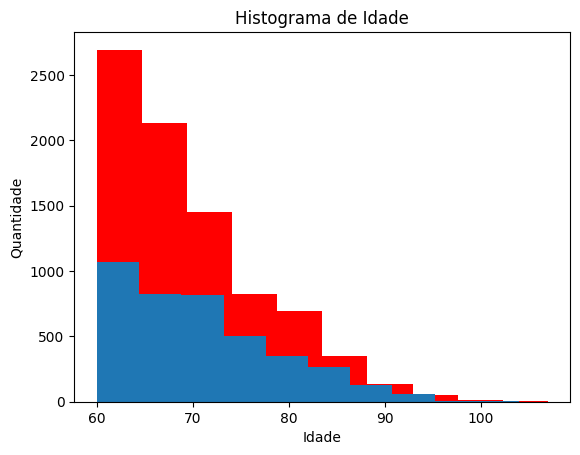

In [9]:
# Plota o histograma da idade das pessoas do DataFrame df_uniao em vermelho
plt.hist(df_uniao['C008'], color='red')
# Plota o histograma da idade das pessoas com artrite/reumatismo
plt.hist(df_atri_reu['C008'])
# Adiciona o título ao gráfico
plt.title('Histograma de Idade')
# Adiciona o rótulo do eixo X
plt.xlabel('Idade')
# Adiciona o rótulo do eixo Y
plt.ylabel('Quantidade')
# (Esta linha não executa nada, deveria ser plt.show() para exibir o gráfico)
plt.plot

### Visualização da distribuição de idade
Esta célula plota histogramas da idade das pessoas saudáveis e das pessoas com artrite/reumatismo, permitindo comparar as distribuições.


ANÁLISE GEOGRÁFICA: 1. População Idosa Geral (60+)

--- Número de Entrevistados por Região ---
Nome_Regiao
Nordeste        15183
Sudeste         10655
Norte            7126
Sul              6041
Centro-Oeste     4549

--- Número de Entrevistados por Estado ---
Nome_Estado
São Paulo              3207
Rio de Janeiro         2991
Minas Gerais           2758
Ceará                  2260
Maranhão               2248
Rio Grande do Sul      2128
Santa Catarina         1959
Paraná                 1954
Pernambuco             1911
Pará                   1785
Espírito Santo         1699
Bahia                  1672
Rio Grande do Norte    1574
Paraíba                1562
Piauí                  1446
Alagoas                1416
Mato Grosso do Sul     1365
Amazonas               1328
Goiás                  1318
Sergipe                1094
Mato Grosso             989
Tocantins               911
Distrito Federal        877
Rondônia                858
Acre                    831
Roraima                 76

C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1071938743.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=d_geo, x='Nome_Regiao', order=contagem_regiao.index, palette='viridis')


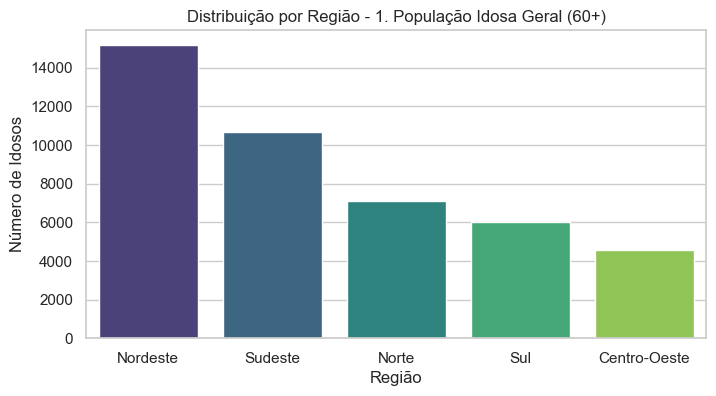

C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1071938743.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=d_geo, x='Nome_Estado', order=contagem_estado.index, palette='magma')


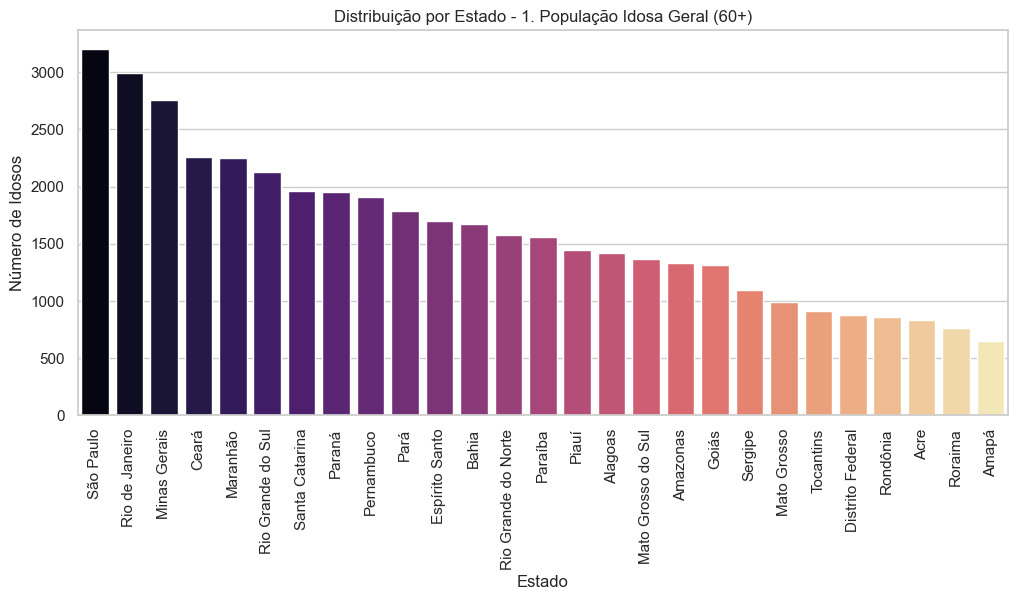


ANÁLISE GEOGRÁFICA: 2. Idosos Saudáveis (Sem doenças crônicas)

--- Número de Entrevistados por Região ---
Nome_Regiao
Nordeste        1478
Sudeste         1003
Norte            825
Sul              550
Centro-Oeste     476

--- Número de Entrevistados por Estado ---
Nome_Estado
Rio de Janeiro         322
São Paulo              275
Minas Gerais           240
Maranhão               239
Paraná                 204
Ceará                  203
Pernambuco             200
Pará                   198
Santa Catarina         175
Bahia                  173
Rio Grande do Sul      171
Amazonas               170
Espírito Santo         166
Piauí                  154
Mato Grosso do Sul     144
Alagoas                140
Paraíba                139
Rio Grande do Norte    134
Mato Grosso            121
Goiás                  115
Tocantins              105
Acre                   103
Sergipe                 96
Distrito Federal        96
Rondônia                94
Roraima                 89
Amapá            

C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1071938743.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=d_geo, x='Nome_Regiao', order=contagem_regiao.index, palette='viridis')


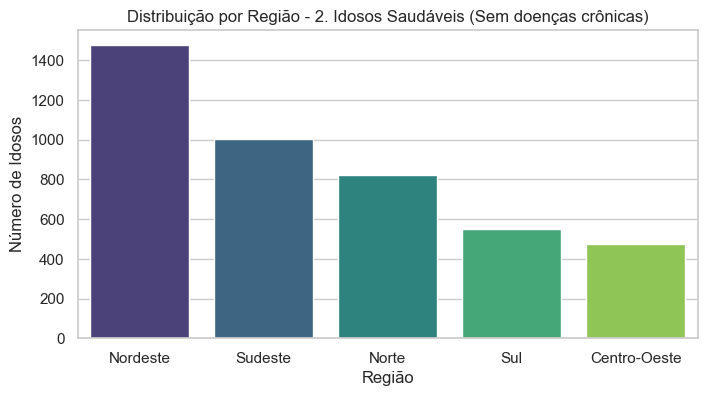

C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1071938743.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=d_geo, x='Nome_Estado', order=contagem_estado.index, palette='magma')


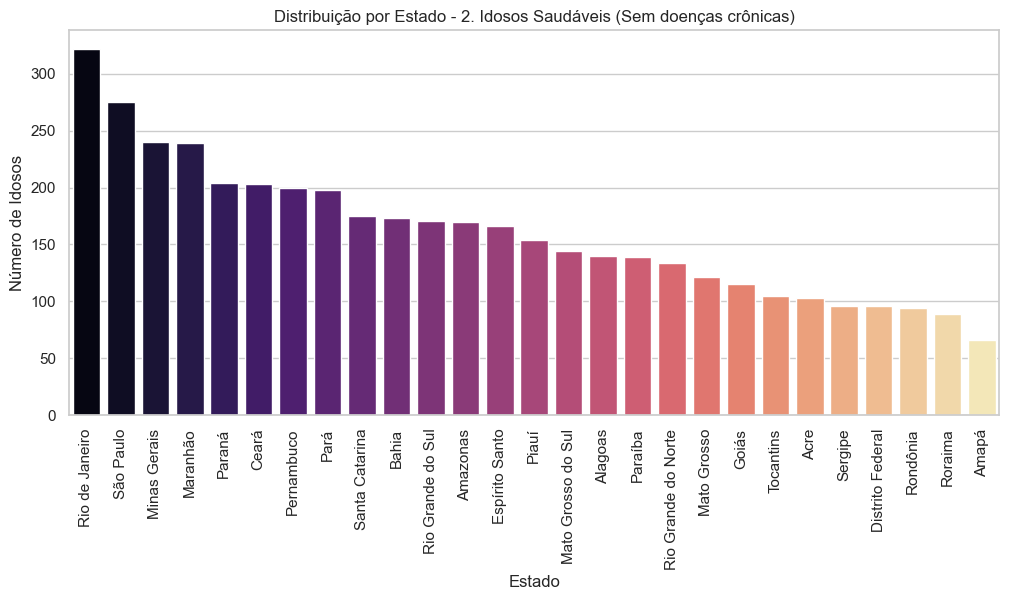


ANÁLISE GEOGRÁFICA: 3. Idosos com Artrite/Reumatismo

--- Número de Entrevistados por Região ---
Nome_Regiao
Nordeste        1392
Sudeste         1012
Norte            634
Sul              581
Centro-Oeste     406

--- Número de Entrevistados por Estado ---
Nome_Estado
São Paulo              297
Rio de Janeiro         286
Minas Gerais           259
Ceará                  215
Rio Grande do Sul      206
Paraná                 200
Pará                   176
Santa Catarina         175
Pernambuco             172
Espírito Santo         170
Maranhão               160
Paraíba                158
Rio Grande do Norte    155
Goiás                  149
Bahia                  146
Mato Grosso do Sul     141
Piauí                  136
Alagoas                128
Amazonas               126
Sergipe                122
Acre                    82
Tocantins               75
Rondônia                70
Mato Grosso             65
Amapá                   62
Distrito Federal        51
Roraima                 43


C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1071938743.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=d_geo, x='Nome_Regiao', order=contagem_regiao.index, palette='viridis')


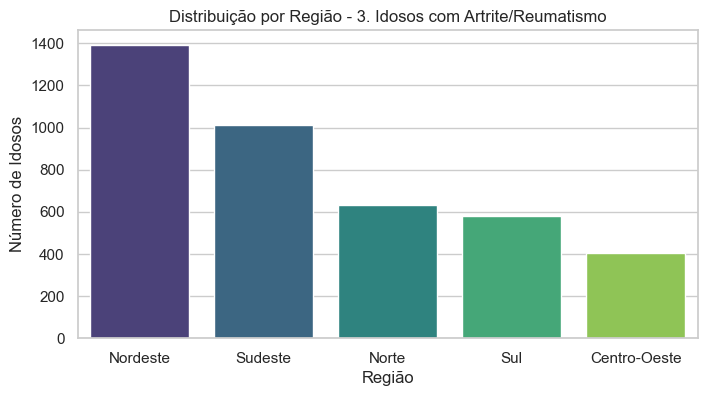

C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1071938743.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=d_geo, x='Nome_Estado', order=contagem_estado.index, palette='magma')


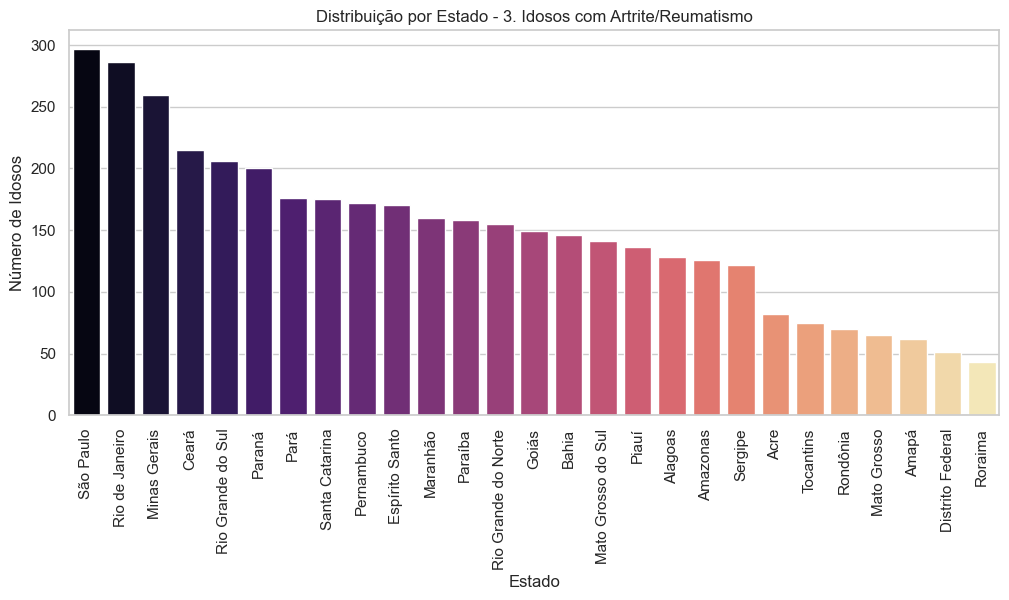


ANÁLISE GEOGRÁFICA: 4. Idosos APENAS com Artrite/Reumatismo

--- Número de Entrevistados por Região ---
Nome_Regiao
Nordeste        177
Sudeste         102
Norte            84
Sul              56
Centro-Oeste     53

--- Número de Entrevistados por Estado ---
Nome_Estado
Rio de Janeiro         36
Maranhão               32
Pará                   31
São Paulo              26
Ceará                  24
Rio Grande do Norte    23
Rio Grande do Sul      23
Minas Gerais           22
Paraíba                21
Piauí                  19
Mato Grosso do Sul     19
Goiás                  19
Amazonas               18
Espírito Santo         18
Paraná                 17
Bahia                  16
Santa Catarina         16
Pernambuco             15
Alagoas                15
Sergipe                12
Tocantins              11
Mato Grosso            11
Acre                    9
Roraima                 7
Rondônia                4
Amapá                   4
Distrito Federal        4


C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1071938743.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=d_geo, x='Nome_Regiao', order=contagem_regiao.index, palette='viridis')


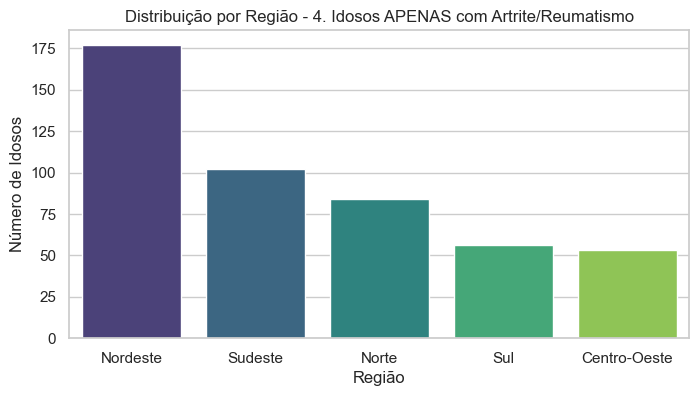

C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1071938743.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=d_geo, x='Nome_Estado', order=contagem_estado.index, palette='magma')


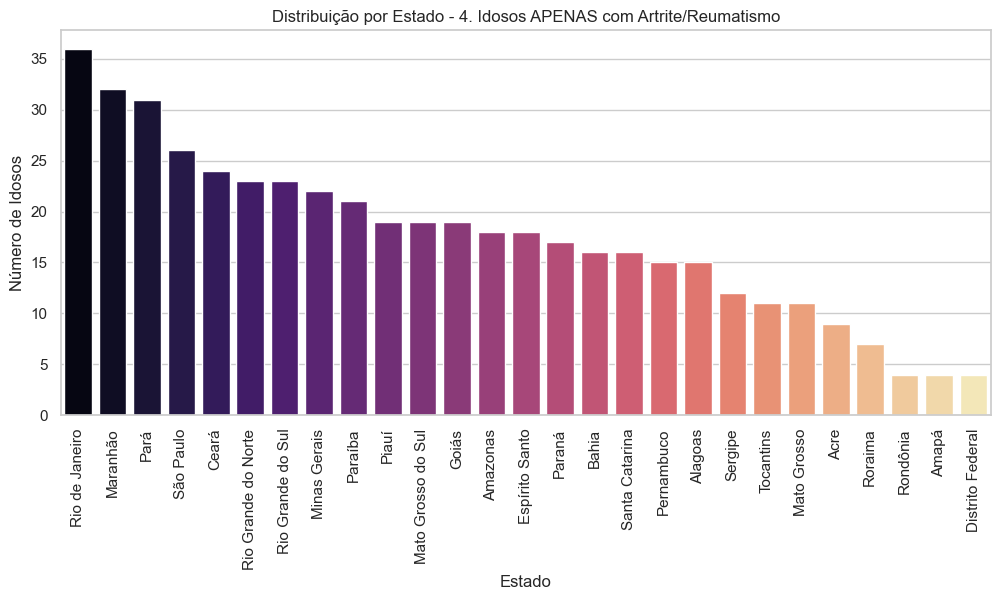

In [10]:
# Importa bibliotecas para análise geográfica e visualização
import pandas as pd  # Biblioteca para manipulação de dados
import matplotlib.pyplot as plt  # Biblioteca para gráficos
import seaborn as sns  # Biblioteca para gráficos avançados

# Dicionário de estados brasileiros para mapeamento
map_estados = { 
    '11' : 'Rondônia', '12' : 'Acre', '13' : 'Amazonas', '14' : 'Roraima', 
    '15' : 'Pará', '16' : 'Amapá', '17' : 'Tocantins', '21' : 'Maranhão', 
    '22' : 'Piauí', '23': 'Ceará', '24':'Rio Grande do Norte', '25' :'Paraíba', 
    '26' :'Pernambuco', '27':'Alagoas', '28':'Sergipe', '29':'Bahia', 
    '31':'Minas Gerais', '32':'Espírito Santo', '33':'Rio de Janeiro', 
    '35':'São Paulo', '41':'Paraná', '42':'Santa Catarina', 
    '43':'Rio Grande do Sul', '50':'Mato Grosso do Sul', 
    '51':'Mato Grosso', '52':'Goiás', '53':'Distrito Federal'
}

# Dicionário de regiões baseado no primeiro número do código do estado
map_regioes = {
    '1': 'Norte', '2': 'Nordeste', '3': 'Sudeste', '4': 'Sul', '5': 'Centro-Oeste'
}

# Função para aplicar a transformação geográfica em qualquer base de dados
def preparar_dados_geograficos(dataframe):
    # Cria uma cópia para evitar avisos do pandas
    d = dataframe.copy()
    
    # Renomeia a coluna 'V0001' para 'Estado'
    d = d.rename(columns={'V0001': 'Estado'})
    
    # Garante que o formato seja string e remove casas decimais (caso o pandas tenha lido como 11.0)
    d['Codigo_Estado'] = d['Estado'].astype(str).str.split('.').str[0]
    
    # Aplica o mapeamento dos estados
    d['Nome_Estado'] = d['Codigo_Estado'].map(map_estados)
    
    # Cria a região capturando apenas o primeiro dígito do código do estado
    d['Nome_Regiao'] = d['Codigo_Estado'].str[0].map(map_regioes)
    
    return d

# Aplica a transformação para as 4 bases de dados do projeto
df_geo = preparar_dados_geograficos(df)
df_bem_geo = preparar_dados_geograficos(df_bem)
df_atri_reu_geo = preparar_dados_geograficos(df_atri_reu)
df_atri_reu_puro_geo = preparar_dados_geograficos(df_atri_reu_puro)

# Função para imprimir os cálculos e plotar os gráficos
def analisar_geografia(d_geo, titulo):
    print(f"\n==================================================")
    print(f"ANÁLISE GEOGRÁFICA: {titulo}")
    print(f"==================================================")
    
    # Cálculo do número de entrevistados por Região
    contagem_regiao = d_geo['Nome_Regiao'].value_counts()
    print(f"\n--- Número de Entrevistados por Região ---")
    print(contagem_regiao.to_string())
    
    # Cálculo do número de entrevistados por Estado
    contagem_estado = d_geo['Nome_Estado'].value_counts()
    print(f"\n--- Número de Entrevistados por Estado ---")
    print(contagem_estado.to_string())
    
    # Configuração visual dos gráficos
    sns.set_theme(style="whitegrid")
    
    # Gráfico 1: Distribuição por Região
    plt.figure(figsize=(8, 4))
    sns.countplot(data=d_geo, x='Nome_Regiao', order=contagem_regiao.index, palette='viridis')
    plt.title(f'Distribuição por Região - {titulo}')
    plt.ylabel('Número de Idosos')
    plt.xlabel('Região')
    plt.show()

    # Gráfico 2: Distribuição por Estado
    plt.figure(figsize=(12, 5))
    sns.countplot(data=d_geo, x='Nome_Estado', order=contagem_estado.index, palette='magma')
    plt.title(f'Distribuição por Estado - {titulo}')
    plt.ylabel('Número de Idosos')
    plt.xlabel('Estado')
    plt.xticks(rotation=90)
    plt.show()

# Executa a análise exploratória visual e os cálculos para os 4 grupos
analisar_geografia(df_geo, "1. População Idosa Geral (60+)")
analisar_geografia(df_bem_geo, "2. Idosos Saudáveis (Sem doenças crônicas)")
analisar_geografia(df_atri_reu_geo, "3. Idosos com Artrite/Reumatismo")
analisar_geografia(df_atri_reu_puro_geo, "4. Idosos APENAS com Artrite/Reumatismo")

### Análise geográfica dos dados
Esta célula prepara os dados para análise geográfica, mapeando estados e regiões, e executa a análise visual e estatística para cada grupo de interesse.

In [11]:
# Importa bibliotecas para manipulação de arquivos, compactação, PDF e Word
import os  # Biblioteca para operações com o sistema operacional
import zipfile  # Biblioteca para criar arquivos ZIP
from datetime import datetime  # Biblioteca para trabalhar com datas e horas
from fpdf import FPDF  # Biblioteca para criar PDFs
from docx import Document  # Biblioteca para criar arquivos Word
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cria pasta para resultados se não existir
output_dir = "../resultados_analise"  # Caminho da pasta de resultados
os.makedirs(output_dir, exist_ok=True)  # Cria a pasta se não existir

# Função para salvar todos os gráficos, estatísticas, PDF e Word
def salvar_analise_completa(d_geo, nome_grupo):
    # Cria subpasta para o grupo
    grupo_dir = os.path.join(output_dir, nome_grupo.replace(" ", "_"))  # Define o caminho da subpasta
    os.makedirs(grupo_dir, exist_ok=True)  # Cria a subpasta se não existir

    # Salva estatísticas em txt
    with open(os.path.join(grupo_dir, "estatisticas.txt"), "w", encoding="utf-8") as f:
        f.write(f"ANÁLISE GEOGRÁFICA: {nome_grupo}\n")  # Escreve o título
        f.write("="*60 + "\n\n")  # Linha de separação

        contagem_regiao = d_geo['Nome_Regiao'].value_counts()  # Conta entrevistados por região
        f.write("--- Número de Entrevistados por Região ---\n")  # Escreve o subtítulo
        f.write(contagem_regiao.to_string() + "\n\n")  # Escreve os valores

        contagem_estado = d_geo['Nome_Estado'].value_counts()  # Conta entrevistados por estado
        f.write("--- Número de Entrevistados por Estado ---\n")  # Escreve o subtítulo
        f.write(contagem_estado.to_string() + "\n")  # Escreve os valores

    # Salva gráfico de regiões
    plt.figure(figsize=(8, 4))  # Define o tamanho do gráfico
    contagem_regiao = d_geo['Nome_Regiao'].value_counts()  # Conta entrevistados por região
    sns.countplot(data=d_geo, x='Nome_Regiao', order=contagem_regiao.index, palette='viridis')  # Plota o gráfico
    plt.title(f'Distribuição por Região - {nome_grupo}')  # Título
    plt.ylabel('Número de Idosos')  # Rótulo Y
    plt.xlabel('Região')  # Rótulo X
    plt.tight_layout()  # Ajusta layout
    plt.savefig(os.path.join(grupo_dir, "grafico_regioes.png"), dpi=300, bbox_inches='tight')  # Salva o gráfico
    plt.close()  # Fecha o gráfico

    # Salva gráfico de estados
    plt.figure(figsize=(12, 5))  # Define o tamanho do gráfico
    contagem_estado = d_geo['Nome_Estado'].value_counts()  # Conta entrevistados por estado
    sns.countplot(data=d_geo, x='Nome_Estado', order=contagem_estado.index, palette='magma')  # Plota o gráfico
    plt.title(f'Distribuição por Estado - {nome_grupo}')  # Título
    plt.ylabel('Número de Idosos')  # Rótulo Y
    plt.xlabel('Estado')  # Rótulo X
    plt.xticks(rotation=90)  # Rotaciona os nomes dos estados
    plt.tight_layout()  # Ajusta layout
    plt.savefig(os.path.join(grupo_dir, "grafico_estados.png"), dpi=300, bbox_inches='tight')  # Salva o gráfico
    plt.close()  # Fecha o gráfico

    # Gera PDF com estatísticas em tabelas
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Arial", size=14)
    pdf.cell(0, 10, f"ANÁLISE GEOGRÁFICA: {nome_grupo}", ln=True, align="C")
    pdf.ln(5)
    pdf.set_font("Arial", size=12)
    # Tabela por Região
    pdf.cell(0, 10, "Número de Entrevistados por Região", ln=True)
    pdf.set_font("Arial", size=10)
    pdf.cell(60, 8, "Região", 1)
    pdf.cell(40, 8, "Quantidade", 1, ln=True)
    for regiao, qtd in contagem_regiao.items():
        pdf.cell(60, 8, str(regiao), 1)
        pdf.cell(40, 8, str(qtd), 1, ln=True)
    pdf.ln(5)
    pdf.set_font("Arial", size=12)
    pdf.cell(0, 10, "Número de Entrevistados por Estado", ln=True)
    pdf.set_font("Arial", size=10)
    pdf.cell(60, 8, "Estado", 1)
    pdf.cell(40, 8, "Quantidade", 1, ln=True)
    for estado, qtd in contagem_estado.items():
        pdf.cell(60, 8, str(estado), 1)
        pdf.cell(40, 8, str(qtd), 1, ln=True)
    pdf.output(os.path.join(grupo_dir, "estatisticas.pdf"))

    # Gera Word com estatísticas em tabelas
    doc = Document()
    doc.add_heading(f'ANÁLISE GEOGRÁFICA: {nome_grupo}', 0)
    doc.add_heading('Número de Entrevistados por Região', level=1)
    table_regiao = doc.add_table(rows=1, cols=2)
    hdr_cells = table_regiao.rows[0].cells
    hdr_cells[0].text = 'Região'
    hdr_cells[1].text = 'Quantidade'
    for regiao, qtd in contagem_regiao.items():
        row_cells = table_regiao.add_row().cells
        row_cells[0].text = str(regiao)
        row_cells[1].text = str(qtd)
    doc.add_heading('Número de Entrevistados por Estado', level=1)
    table_estado = doc.add_table(rows=1, cols=2)
    hdr_cells = table_estado.rows[0].cells
    hdr_cells[0].text = 'Estado'
    hdr_cells[1].text = 'Quantidade'
    for estado, qtd in contagem_estado.items():
        row_cells = table_estado.add_row().cells
        row_cells[0].text = str(estado)
        row_cells[1].text = str(qtd)
    doc.save(os.path.join(grupo_dir, "estatisticas.docx"))

    print(f"✓ Análise salva: {nome_grupo}")  # Mensagem de sucesso

# Salva todas as análises
salvar_analise_completa(df_geo, "1_Populacao_Idosa_Geral")  # Salva análise geral
salvar_analise_completa(df_bem_geo, "2_Idosos_Saudaveis")  # Salva análise de saudáveis
salvar_analise_completa(df_atri_reu_geo, "3_Idosos_com_Artrite")  # Salva análise de artrite/reumatismo
salvar_analise_completa(df_atri_reu_puro_geo, "4_Idosos_APENAS_Artrite")  # Salva análise de artrite/reumatismo puro

print("\n✓ Todas as análises foram salvas!")  # Mensagem final

c:\Users\Pedro\Desktop\Faculdade\Semestre 3\Mineração de Dados\Python\Projeto\Projeto_PNS\.venv\Lib\site-packages\fpdf\__init__.py:41: UserWarning: You have both PyFPDF & fpdf2 installed. Both packages cannot be installed at the same time as they share the same module namespace. To only keep fpdf2, run: pip uninstall --yes pypdf && pip install --upgrade fpdf2
  warnings.warn(
C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1147596476.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=d_geo, x='Nome_Regiao', order=contagem_regiao.index, palette='viridis')  # Plota o gráfico
C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1147596476.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.cou

✓ Análise salva: 1_Populacao_Idosa_Geral


C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1147596476.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=d_geo, x='Nome_Estado', order=contagem_estado.index, palette='magma')  # Plota o gráfico
C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1147596476.py:60: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=14)
C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1147596476.py:61: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, f"ANÁLISE GEOGRÁFICA: {nome_grupo}", ln=True, align="C")
C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1147596476.py:63: DeprecationWarning: Substituting font arial by core font helvetica - This is 

✓ Análise salva: 2_Idosos_Saudaveis


C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1147596476.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=d_geo, x='Nome_Estado', order=contagem_estado.index, palette='magma')  # Plota o gráfico
C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1147596476.py:60: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=14)
C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1147596476.py:61: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, f"ANÁLISE GEOGRÁFICA: {nome_grupo}", ln=True, align="C")
C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1147596476.py:63: DeprecationWarning: Substituting font arial by core font helvetica - This is 

✓ Análise salva: 3_Idosos_com_Artrite


C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1147596476.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=d_geo, x='Nome_Estado', order=contagem_estado.index, palette='magma')  # Plota o gráfico


✓ Análise salva: 4_Idosos_APENAS_Artrite

✓ Todas as análises foram salvas!


C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1147596476.py:60: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=14)
C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1147596476.py:61: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, f"ANÁLISE GEOGRÁFICA: {nome_grupo}", ln=True, align="C")
C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1147596476.py:63: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=12)
C:\Users\Pedro\AppData\Local\Temp\ipykernel_4268\1147596476.py:65: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, "Número de Entrevistados por Região", ln=True)
C:\Users\Pedro\App

### Salvando resultados da análise
Esta célula salva os resultados das análises (estatísticas e gráficos) em arquivos nas pastas correspondentes a cada grupo, facilitando o compartilhamento e organização dos dados.

In [12]:
# Cria o arquivo ZIP com todos os resultados gerados na análise.
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")  # Gera um timestamp para identificar o arquivo ZIP
nome_zip = f"analise_exploratoria_{timestamp}.zip"  # Define o nome do arquivo ZIP com o timestamp
caminho_zip = os.path.join("..", nome_zip)  # Define o caminho onde o ZIP será salvo (um nível acima da pasta atual)

with zipfile.ZipFile(caminho_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:  # Abre o arquivo ZIP para escrita
    for pasta_raiz, pastas, arquivos in os.walk(output_dir):  # Percorre todas as subpastas e arquivos dentro da pasta de resultados
        for arquivo in arquivos:  # Para cada arquivo encontrado
            caminho_completo = os.path.join(pasta_raiz, arquivo)  # Caminho completo do arquivo
            caminho_relativo = os.path.relpath(caminho_completo, output_dir)  # Caminho relativo para manter a estrutura dentro do ZIP
            zipf.write(caminho_completo, caminho_relativo)  # Adiciona o arquivo ao ZIP

print(f"\n🎉 ZIP criado com sucesso: {nome_zip}")  # Mensagem de sucesso ao criar o ZIP
print(f"📁 Localização: {os.path.abspath(caminho_zip)}")  # Mostra o caminho absoluto do arquivo ZIP
print(f"📊 Total de arquivos: {len([f for _, _, files in os.walk(output_dir) for f in files])}")  # Mostra o total de arquivos incluídos no ZIP


🎉 ZIP criado com sucesso: analise_exploratoria_20260308_095122.zip
📁 Localização: c:\Users\Pedro\Desktop\Faculdade\Semestre 3\Mineração de Dados\Python\Projeto\Projeto_PNS\analise_exploratoria_20260308_095122.zip
📊 Total de arquivos: 20


## Explicação da célula acima
Esta célula cria um arquivo ZIP contendo todos os resultados gerados na análise exploratória. Ela percorre todas as subpastas e arquivos dentro da pasta de resultados, adicionando-os ao ZIP. O nome do arquivo ZIP inclui um timestamp para facilitar a identificação. Ao final, exibe mensagens informando o sucesso da operação, o caminho do arquivo ZIP e o total de arquivos incluídos.